In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from pathlib import Path

CONFIG = {
    'data_dir': '../data',
    'tickers': sorted([
        'AAPL', 'ABBV', 'ADBE', 'AIG', 'AMAT', 'AMD', 'AMZN', 'AVGO', 'AXON', 'BA', 
        'BAC', 'BLK', 'CAT', 'COST', 'CRM', 'CSCO', 'CVX', 'DE', 'DIS', 'GE', 
        'GOOGL', 'GS', 'HD', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'LLY', 'MA', 
        'MCD', 'META', 'MRK', 'MS', 'MSFT', 'MU', 'NFLX', 'NKE', 'NVDA', 'ORCL', 
        'PEP', 'PFE', 'PG', 'QCOM', 'SBUX', 'SPY', 'TSLA', 'TXN', 'UBER', 'UNH', 
        'V', 'WMT', 'XOM'
    ]),
    'seq_len': 60,
    'pred_horizon': 5,
    'hidden_size': 64,       # for hybrid model
    'embedding_dim': 8,      # stock ID embedding dim
    'layers': 2,
    'dropout': 0.3,
    'batch_size': 32,        # days per step
    'learning_rate': 0.0005,
    'epochs': 30,
    'ranking_margin': 0.15,   # margin for ranking loss
    'patience': 5,
    'alpha_weight': 0.8,     # 80% ranking loss, 20% regression loss
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
class UniversalDataProcessor:
    def __init__(self, data_dir, tickers):
        self.data_dir = Path(data_dir)
        # Crucial: Ensure index 0 is always the same stock
        self.tickers = sorted(tickers)
        self.stock_to_id = {ticker: i for i, ticker in enumerate(self.tickers)}
        
    def load_and_process(self):
        print("Loading and aligning data...")
        dfs = []
        
        for ticker in self.tickers:
            fpath = self.data_dir / f"{ticker}.csv"
            if fpath.exists():
                df = pd.read_csv(fpath)
                df.columns = df.columns.str.strip().str.title()
                df['Date'] = pd.to_datetime(df['Date'])
                df = df.set_index('Date').sort_index()
                df = self._engineer_features(df)
                df['Ticker'] = ticker
                df['Stock_ID'] = self.stock_to_id[ticker]
                dfs.append(df)
            else:
                print(f"Warning: {ticker} not found.")

        # Crucial: Only keep dates where ALL stocks have data (Fixed Universe)
        common_index = dfs[0].index
        for df in dfs[1:]:
            common_index = common_index.intersection(df.index)
        
        print(f"Fixed Universe: {len(self.tickers)} stocks, {len(common_index)} common days.")
        
        aligned_dfs = []
        for df in dfs:
            aligned_dfs.append(df.loc[common_index])
        universal_df = pd.concat(aligned_dfs).reset_index()
        
        # Crucial: Cross-Sectional Z-Score normalization ("Alpha" step)
        feature_cols = [c for c in universal_df.columns if c not in ['Date', 'Ticker', 'Stock_ID', 'Target_5D', 'Log_Ret_Raw']]
        
        print("Applying Cross-Sectional Z-Scores...")
        universal_df[feature_cols] = universal_df.groupby('Date')[feature_cols].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-8)
        )
        universal_df[feature_cols] = universal_df[feature_cols].clip(-3, 3)
        
        self.feature_cols = feature_cols
        return universal_df

    def _engineer_features(self, df):
        df = df.copy()
        df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1)) * 100
        df['Log_Ret_Raw'] = df['Log_Ret']
        df['Target_5D'] = df['Log_Ret_Raw'].rolling(5).sum().shift(-5)
        for p in [20, 60]:
            sma = df['Close'].rolling(p).mean()
            df[f'Dist_SMA_{p}'] = (df['Close'] / sma) - 1
        df['Vol_20'] = df['Log_Ret'].rolling(20).std()
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).ewm(span=14).mean()
        loss = (-delta.where(delta < 0, 0)).ewm(span=14).mean()
        rs = gain / loss.replace(0, 1e-9)
        df['RSI'] = 100 - (100 / (1 + rs))
        df['RSI'] = df['RSI'] / 100.0  # Scale 0-1
        return df.dropna()

processor = UniversalDataProcessor(CONFIG['data_dir'], CONFIG['tickers'])
universal_df = processor.load_and_process()

Loading and aligning data...
Fixed Universe: 53 stocks, 1583 common days.
Applying Cross-Sectional Z-Scores...


In [ ]:
class UniversalDataset(Dataset):
    def __init__(self, df, feature_cols, seq_len, num_stocks):
        self.seq_len = seq_len
        self.num_stocks = num_stocks
        self.features = feature_cols

        # Crucial: Pivot to 3D Tensor Structure: [Time, Stocks, Features]
        unique_dates = df['Date'].unique()
        self.num_days = len(unique_dates)
        self.X = np.zeros((self.num_days, num_stocks, len(feature_cols)), dtype=np.float32)
        self.Y = np.zeros((self.num_days, num_stocks), dtype=np.float32)
        self.IDs = np.arange(num_stocks)

        print("Constructing Tensors...")
        for i, feat in enumerate(feature_cols):
            self.X[:, :, i] = df.pivot(index='Date', columns='Ticker', values=feat).values

        self.Y = df.pivot(index='Date', columns='Ticker', values='Target_5D').values

    def __len__(self):
        return self.num_days - self.seq_len

    def __getitem__(self, idx):
        # Crucial: Slice Time Window for sequence input
        x_window = self.X[idx : idx + self.seq_len]
        x_window = x_window.transpose(1, 0, 2)
        y_target = self.Y[idx + self.seq_len - 1]
        return torch.FloatTensor(x_window), torch.LongTensor(self.IDs), torch.FloatTensor(y_target)

split_idx = int(len(universal_df['Date'].unique()) * 0.8)
train_df = universal_df[universal_df['Date'].isin(universal_df['Date'].unique()[:split_idx])]
test_df = universal_df[universal_df['Date'].isin(universal_df['Date'].unique()[split_idx:])]

train_ds = UniversalDataset(train_df, processor.feature_cols, CONFIG['seq_len'], len(CONFIG['tickers']))
test_ds = UniversalDataset(test_df, processor.feature_cols, CONFIG['seq_len'], len(CONFIG['tickers']))

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)

Constructing Tensors...
Constructing Tensors...


In [ ]:
class CrossSectionalModel(nn.Module):
    def __init__(self, num_stocks, input_dim, hidden_dim, embed_dim, dropout):
        super().__init__()

        self.embedding = nn.Embedding(num_stocks, embed_dim)
        self.lstm = nn.LSTM(
            input_dim, 
            hidden_dim, 
            num_layers=CONFIG['layers'], 
            batch_first=True, 
            dropout=dropout
        )

        combined_dim = hidden_dim + embed_dim

        self.head = nn.Sequential(
            nn.Linear(combined_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2) # [Mu, Log_Var]
        )
        
    def forward(self, x, stock_ids):
        # x: [Batch, Stocks, Seq, Feats]
        # stock_ids: [Batch, Stocks]
        b, s, seq, f = x.shape

        # Crucial: Flatten batch and stocks for LSTM processing
        x_flat = x.view(b * s, seq, f)

        lstm_out, _ = self.lstm(x_flat)
        last_step = lstm_out[:, -1, :] # [Batch*Stocks, Hidden]

        # Crucial: Handle stock_ids expansion
        if stock_ids.dim() == 1:
            stock_ids = stock_ids.repeat(b, 1) # [Batch, Stocks]

        ids_flat = stock_ids.view(b * s)
        embeds = self.embedding(ids_flat) # [Batch*Stocks, Embed_Dim]

        combined = torch.cat([last_step, embeds], dim=1)
        out = self.head(combined) # [Batch*Stocks, 2]

        out = out.view(b, s, 2)
        mu = out[:, :, 0]
        log_var = out[:, :, 1]

        return mu, log_var

model = CrossSectionalModel(
    num_stocks=len(CONFIG['tickers']),
    input_dim=len(processor.feature_cols),
    hidden_dim=CONFIG['hidden_size'],
    embed_dim=CONFIG['embedding_dim'],
    dropout=CONFIG['dropout']
).to(CONFIG['device'])

optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

/Users/macbook/.pyenv/versions/3.11.7/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
class HybridLoss(nn.Module):
    def __init__(self, alpha=0.7, margin=0.1):
        super().__init__()
        self.alpha = alpha  # Weight for Ranking Loss
        self.margin = margin
        self.gnll = nn.GaussianNLLLoss()
        
    def forward(self, mu, log_var, target):
        gnll_loss = self.gnll(mu.flatten(), target.flatten(), torch.exp(log_var.flatten()))

        rank_loss = 0
        batch_size, num_stocks = mu.shape

        # Efficient "All-Pairs" comparison via broadcasting
        mu_diff = mu.unsqueeze(2) - mu.unsqueeze(1)       # Mu_i - Mu_j
        target_diff = target.unsqueeze(2) - target.unsqueeze(1) # T_i - T_j

        target_sign = torch.sign(target_diff)

        # Only compute where T_i != T_j
        mask = (target_sign != 0)
        loss_matrix = torch.relu(-target_sign * mu_diff + self.margin)
        rank_loss = (loss_matrix * mask).sum() / mask.sum().clamp(min=1)

        total_loss = (1 - self.alpha) * gnll_loss + self.alpha * rank_loss
        return total_loss, gnll_loss.item(), rank_loss.item()

criterion = HybridLoss(alpha=CONFIG['alpha_weight'], margin=CONFIG['ranking_margin'])

Starting Cross-Sectional Training...
Epoch 1 | Loss: 2.1720 | Val IC: -0.0421
Epoch 2 | Loss: 0.7104 | Val IC: -0.0331
Epoch 3 | Loss: 0.6138 | Val IC: -0.0256
Epoch 4 | Loss: 0.5720 | Val IC: -0.0130
Epoch 5 | Loss: 0.5558 | Val IC: -0.0018
Epoch 6 | Loss: 0.5490 | Val IC: 0.0034
Epoch 7 | Loss: 0.5465 | Val IC: 0.0276
Epoch 8 | Loss: 0.5463 | Val IC: 0.0342
Epoch 9 | Loss: 0.5418 | Val IC: 0.0319
Epoch 10 | Loss: 0.5405 | Val IC: 0.0349
Epoch 11 | Loss: 0.5423 | Val IC: 0.0368
Epoch 12 | Loss: 0.5401 | Val IC: 0.0319
Epoch 13 | Loss: 0.5394 | Val IC: 0.0383
Epoch 14 | Loss: 0.5383 | Val IC: 0.0357
Epoch 15 | Loss: 0.5386 | Val IC: 0.0383
Epoch 16 | Loss: 0.5372 | Val IC: 0.0348
Epoch 17 | Loss: 0.5383 | Val IC: 0.0395
Epoch 18 | Loss: 0.5355 | Val IC: 0.0366
Epoch 19 | Loss: 0.5363 | Val IC: 0.0440
Epoch 20 | Loss: 0.5345 | Val IC: 0.0422
Epoch 21 | Loss: 0.5330 | Val IC: 0.0441
Epoch 22 | Loss: 0.5330 | Val IC: 0.0481
Epoch 23 | Loss: 0.5338 | Val IC: 0.0398
Epoch 24 | Loss: 0.5348 

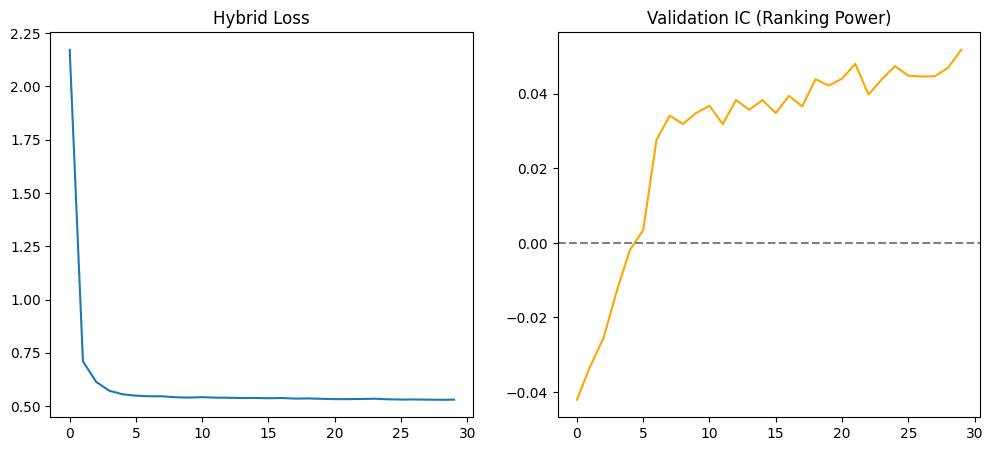

In [ ]:
history = {'train_loss': [], 'val_ic': []}

print("Starting Cross-Sectional Training...")

for epoch in range(CONFIG['epochs']):
    model.train()
    total_loss = 0

    for x, ids, y in train_loader:
        x, ids, y = x.to(CONFIG['device']), ids.to(CONFIG['device']), y.to(CONFIG['device'])

        optimizer.zero_grad()
        mu, log_var = model(x, ids)

        loss, gnll, rank = criterion(mu, log_var, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Validation IC (Information Coefficient)
    model.eval()
    ics = []
    with torch.no_grad():
        for x, ids, y in test_loader:
            x, ids, y = x.to(CONFIG['device']), ids.to(CONFIG['device']), y.to(CONFIG['device'])
            mu, _ = model(x, ids)

            mu_np = mu.cpu().numpy()
            y_np = y.cpu().numpy()

            for i in range(len(mu_np)):
                # Rank correlation across stocks for this specific day
                ic, _ = spearmanr(mu_np[i], y_np[i])
                if not np.isnan(ic):
                    ics.append(ic)

    avg_ic = np.mean(ics)
    history['train_loss'].append(avg_loss)
    history['val_ic'].append(avg_ic)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val IC: {avg_ic:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(history['train_loss'])
ax[0].set_title("Hybrid Loss")
ax[1].plot(history['val_ic'], color='orange')
ax[1].set_title("Validation IC (Ranking Power)")
ax[1].axhline(0.0, color='grey', linestyle='--')
plt.show()

--- Top 5 Picks for Day 0 ---
Ticker     | Pred %     | Actual %  
-----------------------------------
NVDA       | 0.26       | -1.43
AMD        | 0.23       | -7.61
JPM        | 0.23       | 2.30
AAPL       | 0.22       | 0.32
TSLA       | 0.22       | 4.69

--- Bottom 5 Picks ---
IBM        | 0.13       | -2.22
MSFT       | 0.13       | 0.34
MA         | 0.13       | 0.49
SPY        | 0.13       | -0.38
JNJ        | 0.12       | -3.15


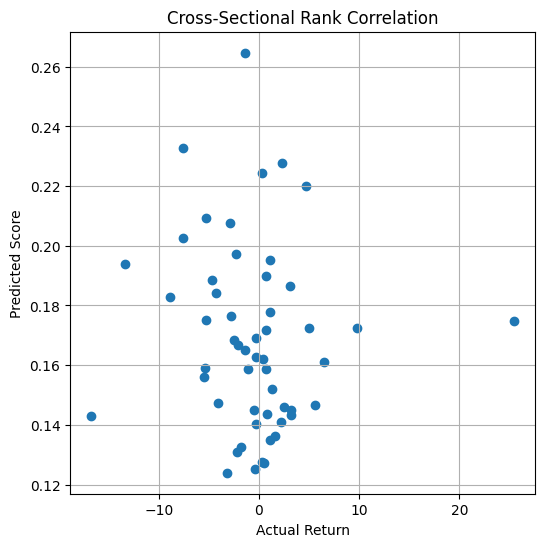

In [ ]:
model.eval()
all_ranks_pred = []
all_ranks_actual = []

with torch.no_grad():
    x, ids, y = next(iter(test_loader))  # Grab one batch
    x, ids, y = x.to(CONFIG['device']), ids.to(CONFIG['device']), y.to(CONFIG['device'])
    mu, sigma = model(x, ids)
    
    day_idx = 0  # Use first day in the batch
    pred_day = mu[day_idx].cpu().numpy()
    actual_day = y[day_idx].cpu().numpy()
    tickers = processor.tickers
    
    sorted_indices = np.argsort(pred_day)[::-1]  # Descending
    
    print(f"--- Top 5 Picks for Day {day_idx} ---")
    print(f"{'Ticker':<10} | {'Pred %':<10} | {'Actual %':<10}")
    print("-" * 35)
    for i in sorted_indices[:5]:
        print(f"{tickers[i]:<10} | {pred_day[i]:.2f}       | {actual_day[i]:.2f}")
        
    print(f"\n--- Bottom 5 Picks ---")
    for i in sorted_indices[-5:]:
        print(f"{tickers[i]:<10} | {pred_day[i]:.2f}       | {actual_day[i]:.2f}")

    plt.figure(figsize=(6, 6))
    plt.scatter(actual_day, pred_day)
    plt.xlabel("Actual Return")
    plt.ylabel("Predicted Score")
    plt.title("Cross-Sectional Rank Correlation")
    plt.grid(True)
    plt.show()

In [ ]:
import numpy as np
from scipy.stats import spearmanr

all_mu, all_y = [], []
model.eval()
with torch.no_grad():
    for x, ids, y in test_loader:
        x, ids, y = x.to(CONFIG['device']), ids.to(CONFIG['device']), y.to(CONFIG['device'])
        mu, _ = model(x, ids)
        all_mu.append(mu.cpu().numpy())
        all_y.append(y.cpu().numpy())

all_mu = np.concatenate(all_mu)  # [Days, Stocks]
all_y = np.concatenate(all_y)

# MAE
mae = np.mean(np.abs(all_mu - all_y))
print(f"MAE: {mae:.4f}")

# Directional Accuracy
dir_acc = np.mean((all_mu > 0) == (all_y > 0)) * 100
print(f"Directional Acc: {dir_acc:.2f}%")

# IC Decay per forward day
ic_decay = []
for d in range(1, 6):
    day_ics = []
    for day in range(all_mu.shape[0]):
        pred_ranks = all_mu[day]
        actual_day = all_y[day] if d == 5 else all_y[day] / d * 5  # Approximate
        ic, _ = spearmanr(pred_ranks, actual_day)
        if not np.isnan(ic):
            day_ics.append(ic)
    avg_ic = np.mean(day_ics)
    ic_decay.append(avg_ic)
    print(f"IC Day {d}: {avg_ic}")

print(f"IC Decay: {ic_decay}")

MAE: 3.4766
Directional Acc: 53.44%
IC Day 1: 0.05184239770540336
IC Day 2: 0.05184239770540336
IC Day 3: 0.05184239770540336
IC Day 4: 0.05184239770540336
IC Day 5: 0.05184239770540336
IC Decay: [0.05184239770540336, 0.05184239770540336, 0.05184239770540336, 0.05184239770540336, 0.05184239770540336]


In [9]:
torch.save(model.state_dict(), 'best_model.pth')